# MobileNetV2 Training Notebook

This notebook trains a MobileNetV2 classifier on the RealWaste dataset using the preprocessing pipeline in `src/preprocess.py`.

It keeps everything inside the notebook: data loading, training, evaluation, and plots.

In [72]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras import layers, Model, optimizers, losses
from tensorflow.keras.applications import MobileNetV2

possible_roots = [Path.cwd(), Path.cwd().parent]
for root in possible_roots:
    if (root / 'src').exists():
        REPO_ROOT = root
        break
else:
    REPO_ROOT = Path.cwd()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocess import prepare_datasets

print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('CPUs:', tf.config.list_physical_devices('CPU'))

TensorFlow version: 2.20.0
GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [63]:
# Config
DATA_DIR = str(REPO_ROOT / 'data' / 'RealWaste')
IMG_SIZE = 224
BATCH_SIZE = 8
TRAIN_EPOCHS = 50
FINE_TUNE_EPOCHS = 50
LR = 1e-3
FT_LR_SCALE = 0.01
DROPOUT = 0.2
UNFREEZE_LAYERS = 20

data = prepare_datasets(
    data_dir=DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    model_type='mobilenetv2',
)

train_ds = data['train_ds']
val_ds = data['val_ds']
test_ds = data['test_ds']
class_weights = data['class_weights']
class_names = data['class_names']
num_classes = len(class_names)

print('Classes:', class_names)
print('Num classes:', num_classes)
print('Data dir:', DATA_DIR)

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class counts: {'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}
Unreadable files: 0
Train: 3800 | Val: 476 | Test: 476
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Num classes: 9
Data dir: /Users/luannguyen/PersonalProjects/garbage-material-classification/data/RealWaste


In [64]:
# Build the MobileNetV2 transfer-learning model
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg',
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Implementation Notes

- This notebook uses **MobileNetV2** with pretrained ImageNet weights as the base model for transfer learning.
- `include_top=False` removes the original ImageNet classifier, and `pooling='avg'` converts the convolutional output into one compact feature vector per image.
- The base model is frozen first with `base_model.trainable = False`, so phase 1 trains only the new classifier head.
- A `Dropout(0.2)` layer is added before the final dense layer to reduce overfitting.
- The output layer uses `Dense(num_classes, activation='softmax')`, which matches this 9-class image classification task.
- The loss function is `SparseCategoricalCrossentropy` because the labels are stored as integer class indices instead of one-hot vectors.


In [65]:
# Phase 1: feature extraction
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRAIN_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping]  # add this
)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - accuracy: 0.4482 - loss: 1.5556 - val_accuracy: 0.6534 - val_loss: 0.9183
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7272 - loss: 0.7291 - val_accuracy: 0.6765 - val_loss: 0.8450
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.7738 - loss: 0.5903 - val_accuracy: 0.6870 - val_loss: 0.8510
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - accuracy: 0.7750 - loss: 0.5701 - val_accuracy: 0.7101 - val_loss: 0.7773
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - accuracy: 0.8055 - loss: 0.5135 - val_accuracy: 0.7038 - val_loss: 0.8303
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.8074 - loss: 0.4857 - val_accuracy: 0.7374 - val_loss: 0.7191
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - accuracy: 0.8347 - loss: 0.4355 - val_accuracy: 0.7458 - val_loss: 0.7138
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.8383 - loss: 0.4139 - 

## Phase 1 Training Notes

- Phase 1 is the **feature extraction** stage. The pretrained MobileNetV2 backbone stays frozen, and only the new classifier head is updated.
- This stage is usually more stable because the pretrained ImageNet features are preserved while the final layer adapts to the RealWaste dataset.
- `EarlyStopping` monitors validation loss and restores the best phase 1 weights automatically.
- In this run, phase 1 already builds a strong baseline: validation accuracy reaches about **0.752**, and the best validation loss is about **0.714**.


In [66]:
# Phase 2: fine-tuning
history2 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

if FINE_TUNE_EPOCHS > 0 and UNFREEZE_LAYERS > 0:
    base_model.trainable = True
    if UNFREEZE_LAYERS < len(base_model.layers):
        for layer in base_model.layers[:-UNFREEZE_LAYERS]:
            layer.trainable = False
        for layer in base_model.layers[-UNFREEZE_LAYERS:]:
            layer.trainable = True

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR * FT_LR_SCALE),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    early_stopping_ft = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history2_run = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stopping_ft] 
    )

    history2 = history2_run.history
else:
    print('Fine-tuning skipped because FINE_TUNE_EPOCHS is 0.')

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 60s 113ms/step - accuracy: 0.6593 - loss: 0.9485 - val_accuracy: 0.7248 - val_loss: 0.7869
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 59s 116ms/step - accuracy: 0.7115 - loss: 0.7606 - val_accuracy: 0.7248 - val_loss: 0.8128
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 119ms/step - accuracy: 0.7402 - loss: 0.6705 - val_accuracy: 0.7185 - val_loss: 0.8370
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 65s 126ms/step - accuracy: 0.7412 - loss: 0.6917 - val_accuracy: 0.7122 - val_loss: 0.8261
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 66s 130ms/step - accuracy: 0.7709 - loss: 0.6086 - val_accuracy: 0.7311 - val_loss: 0.8217
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.7917 - loss: 0.5691 - val_accuracy: 0.7437 - val_loss: 0.7824
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 63s 125ms/step - accuracy: 0.8060 - loss: 0.5111 - val_accuracy: 0.7500 - val_loss: 0.7622
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.8000 - loss: 0

## Fine-Tuning Notes

- Phase 2 unfreezes the last part of MobileNetV2 so higher-level pretrained features can adapt more directly to the garbage classification task.
- The learning rate is reduced during this stage because pretrained backbone layers should usually be updated more gently than the new output head.
- A temporary increase in validation loss right after unfreezing is normal. Once more layers become trainable, the optimization problem changes and the model often needs a few epochs to readjust.
- In this run, fine-tuning is helpful overall: validation accuracy improves from the low-0.75 range in phase 1 to about **0.813**, and the best validation loss improves further to about **0.624**.


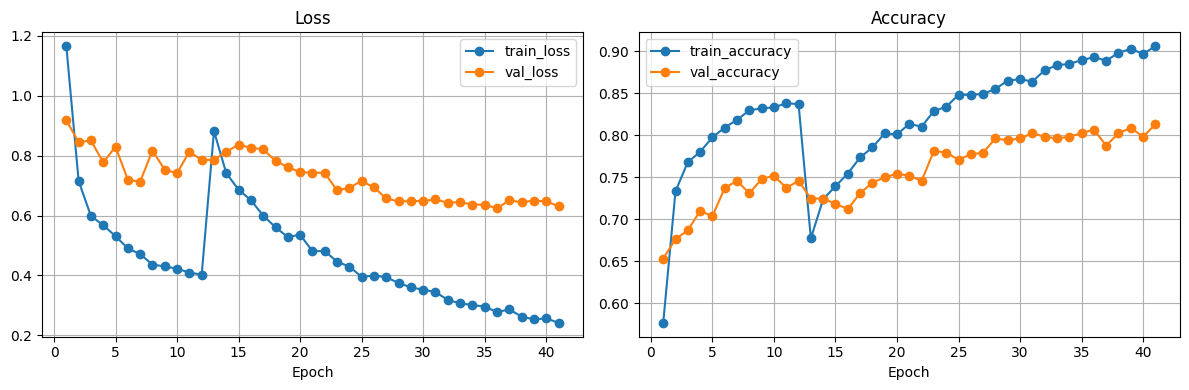

In [67]:
# Plot training curves inline
merged_history = {
    'loss': history1.history.get('loss', []) + history2.get('loss', []),
    'accuracy': history1.history.get('accuracy', []) + history2.get('accuracy', []),
    'val_loss': history1.history.get('val_loss', []) + history2.get('val_loss', []),
    'val_accuracy': history1.history.get('val_accuracy', []) + history2.get('val_accuracy', []),
}

epochs = list(range(1, len(merged_history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, merged_history['loss'], marker='o', label='train_loss')
axes[0].plot(epochs, merged_history['val_loss'], marker='o', label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, merged_history['accuracy'], marker='o', label='train_accuracy')
axes[1].plot(epochs, merged_history['val_accuracy'], marker='o', label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

if len(epochs) == 1:
    for ax in axes:
        ax.set_xlim(0.5, 1.5)

plt.tight_layout()
plt.show()

In [68]:
# Final evaluation

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)
print('Macro precision:', precision_macro)
print('Macro recall:', recall_macro)
print('Macro F1:', f1_macro)
print('Weighted precision:', precision_weighted)
print('Weighted recall:', recall_weighted)
print('Weighted F1:', f1_weighted)
print('\nClassification report:\n')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test loss: 0.5786889791488647
Test accuracy: 0.8088235259056091
Macro precision: 0.814864924602233
Macro recall: 0.8091302161122758
Macro F1: 0.8043863088577571
Weighted precision: 0.8227178169442639
Weighted recall: 0.8088235294117647
Weighted F1: 0.8091136650208673

Classification report:

                     precision    recall  f1-score   support

          Cardboard       0.85      0.89      0.87        46
      Food Organics       0.93      0.63      0.75        41
              Glass       0.74      0.88      0.80        42
              Metal       0.91      0.81      0.86        79
Miscellaneous Trash       0.60      0.74      0.66        50
              Paper       0.76      0.90      0.83        50
            Plastic       0.86      0.76      0.81        92
      Textile Trash       0.85      0.69      0.76        32
         Vegetation       0.83      0.98      0.90        44

           accuracy                           0.81       476
          macro avg       0.81    

##Evaluation Notes

- The overall test result is strong for this project: **80.8% test accuracy** with **macro F1 of 0.804** means the model performs consistently well across all 9 classes, not just the largest ones.
- The weighted F1 (0.809) and macro F1 (0.804) are very close, which suggests class imbalance is being handled well and the model is not over-relying on majority classes.
- The strongest classes are **Vegetation (F1 0.90), Cardboard (F1 0.87), and Metal (F1 0.86)**, which likely have more visually distinct patterns that MobileNetV2 can reliably detect.
- **Miscellaneous Trash** remains the weakest class with F1 0.66, which is expected — it is a catch-all category with no single clear visual pattern, making it inherently harder to classify.
- **Food Organics** has very high precision (0.93) but lower recall (0.63), meaning the model is confident when it predicts Food Organics but misses a noticeable portion of actual Food Organics images, likely confusing them with Vegetation or Miscellaneous Trash.
- **Textile Trash** shows similar behavior — high precision (0.85) but lower recall (0.69), suggesting the model is selective but misses some true Textile examples.
- Fine-tuning clearly helped: the test loss of 0.578 is significantly lower than Phase 1 val loss which plateaued around 0.72, and accuracy improved from the mid-0.74 range in Phase 1 to 0.81 on the final test set.

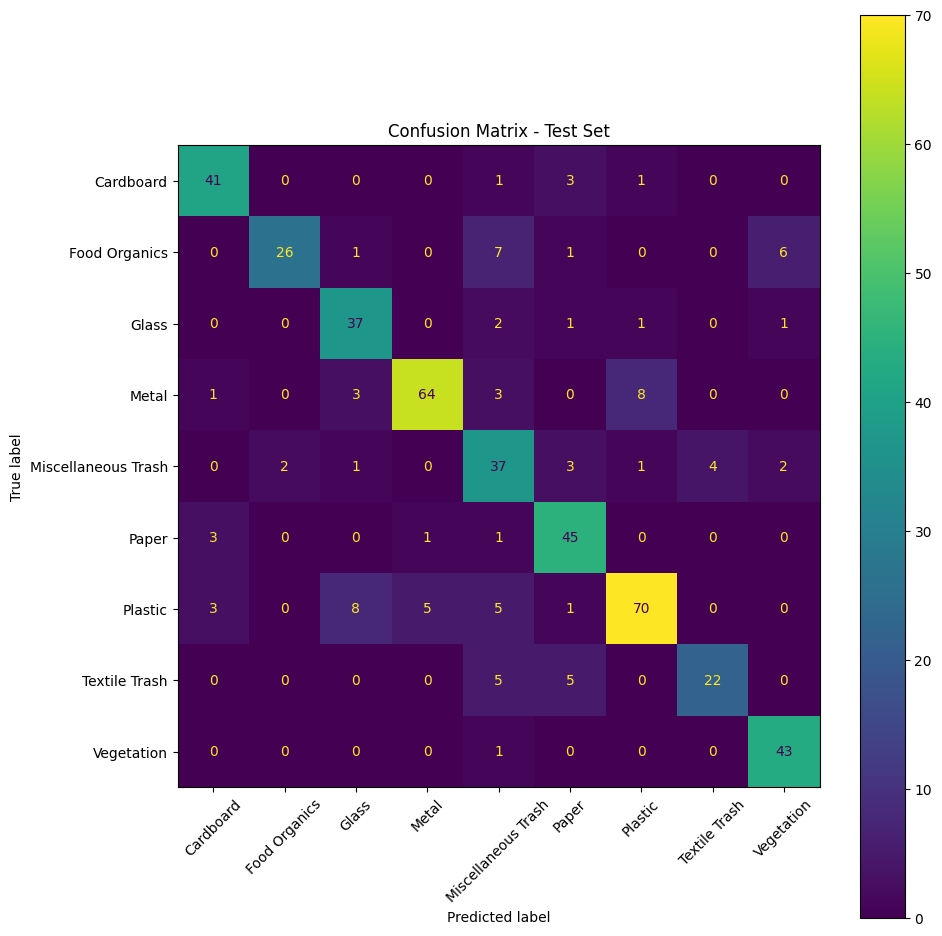

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

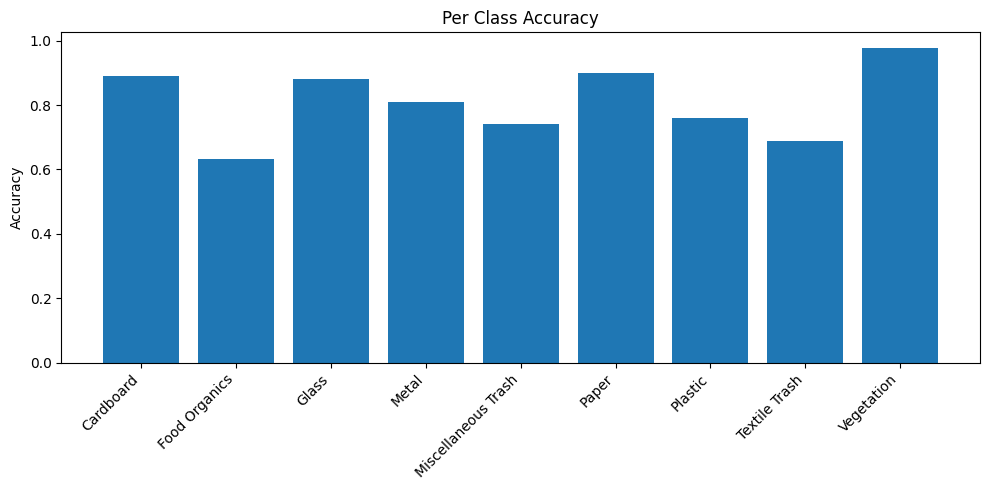

In [70]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(class_names, per_class_acc)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Per Class Accuracy')
plt.tight_layout()
plt.show()

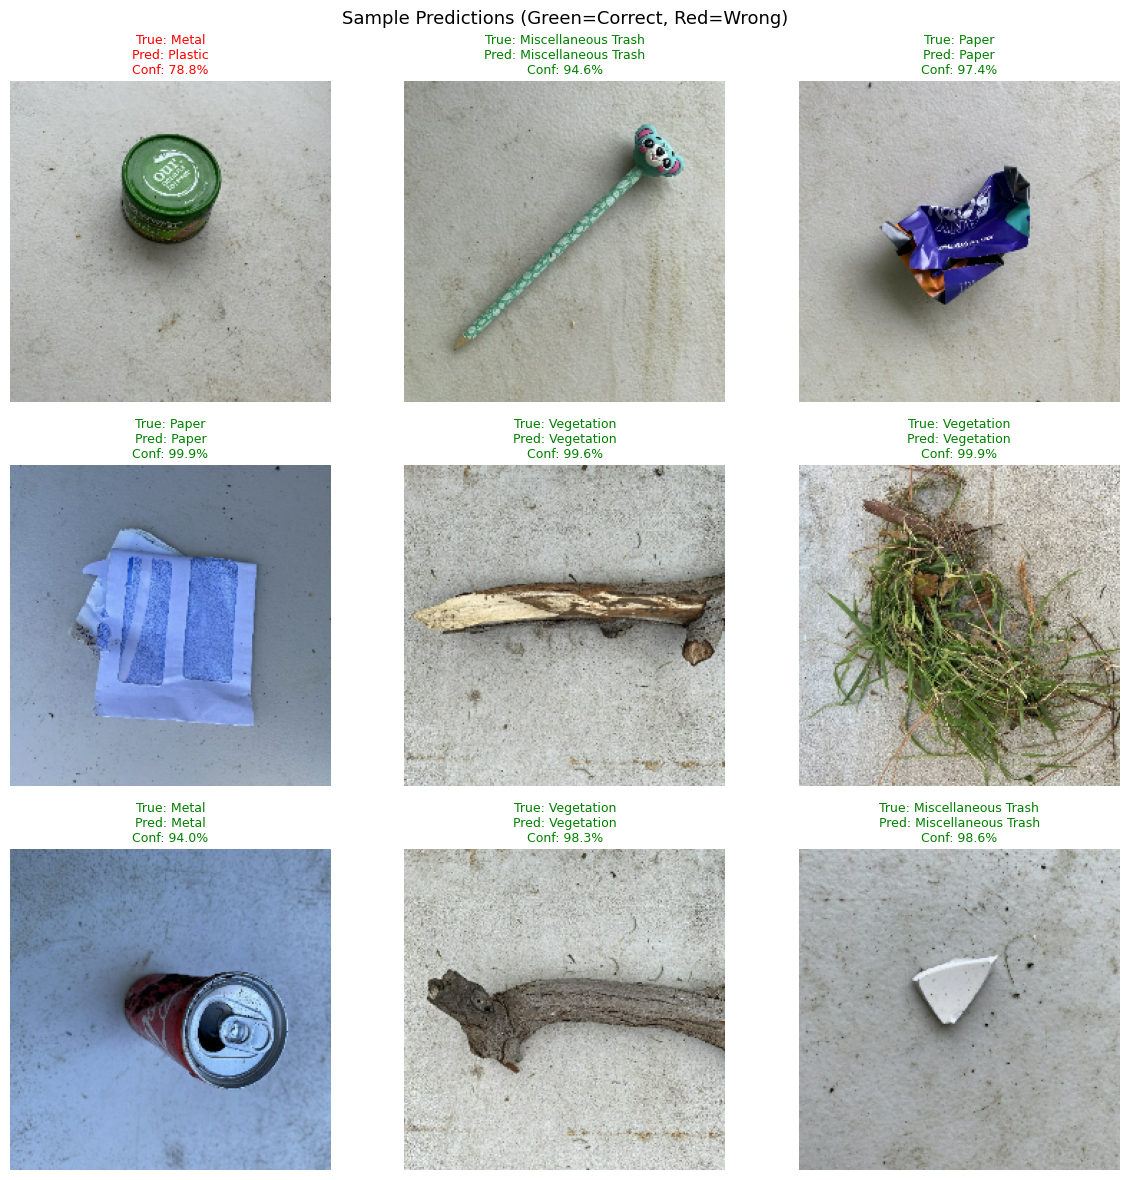

In [71]:
import math

def visualize_predictions(model, test_ds, class_names, num_examples=9):
    images_shown = []
    labels_shown = []
    
    for images, labels in test_ds:
        images_shown.append(images.numpy())
        labels_shown.append(labels.numpy())
        if sum(len(x) for x in images_shown) >= num_examples:
            break
    
    images_shown = np.concatenate(images_shown)[:num_examples]
    labels_shown = np.concatenate(labels_shown)[:num_examples]
    
    probs = model.predict(tf.constant(images_shown), verbose=0)  # softmax probabilities
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)  # ← highest probability = confidence
    
    cols = 3
    rows = math.ceil(num_examples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.ravel()
    
    for i in range(num_examples):
        img = images_shown[i].copy()
        img = (img - img.min()) / (img.max() - img.min())
        
        axes[i].imshow(img)
        
        true_label = class_names[labels_shown[i]]
        pred_label = class_names[preds[i]]
        confidence = confidences[i] * 100  # convert to percentage
        correct = labels_shown[i] == preds[i]
        
        color = 'green' if correct else 'red'
        title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%"  # ← added
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis('off')
    
    for i in range(num_examples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, class_names, num_examples=9)